Initial Centroids:
[[5 8]
 [7 7]]

Cluster Assignments:
[2 3] -> Cluster 0
[5 8] -> Cluster 0
[1 2] -> Cluster 0
[6 9] -> Cluster 0
[7 7] -> Cluster 1


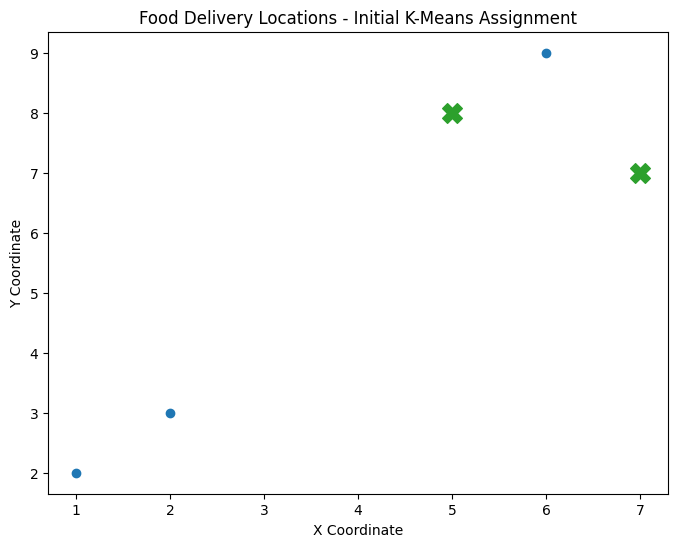

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Food delivery locations
points = np.array([
    [2, 3],
    [5, 8],
    [1, 2],
    [6, 9],
    [7, 7]
])

# Randomly select two initial centroids
np.random.seed(42)
indices = np.random.choice(len(points), 2, replace=False)
centroids = points[indices]

print("Initial Centroids:")
print(centroids)

# Calculate Euclidean distance
def euclidean_distance(point, centroid):
    return np.sqrt(np.sum((point - centroid) ** 2))

# Assign each point to nearest centroid
assignments = []

for point in points:
    distances = [euclidean_distance(point, centroid)
                 for centroid in centroids]
    cluster = np.argmin(distances)
    assignments.append(cluster)

print("\nCluster Assignments:")
for point, cluster in zip(points, assignments):
    print(point, "-> Cluster", cluster)

# Plot points
plt.figure(figsize=(8, 6))

for cluster in range(2):
    cluster_points = points[np.array(assignments) == cluster]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        label=f"Cluster {cluster}"
    )

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Initial Centroids"
)

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Food Delivery Locations - Initial K-Means Assignment")
plt.show()

In [11]:
import numpy as np

def assign_clusters(points, centroids):
    assignments = []

    for point in points:
        distances = []

        for centroid in centroids:
            distance = np.sqrt(
                np.sum((point - centroid) ** 2)
            )
            distances.append(distance)

        # Select centroid with minimum distance
        cluster = np.argmin(distances)
        assignments.append(cluster)

    return assignments


# Sample dataset
points = np.array([
    [2, 3],
    [5, 8],
    [1, 2],
    [6, 9],
    [7, 7]
])

centroids = np.array([
    [2, 3],
    [6, 9]
])

assignments = assign_clusters(points, centroids)

print("Cluster Assignments:")
print(assignments)

Cluster Assignments:
[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


In [12]:
import numpy as np

def assign_clusters(points, centroids, distance_type="euclidean"):

    # Validate distance type
    if distance_type not in ["euclidean", "manhattan"]:
        raise ValueError(
            "distance_type must be 'euclidean' or 'manhattan'"
        )

    assignments = []

    for point in points:
        distances = []

        for centroid in centroids:

            if distance_type == "euclidean":
                # Euclidean distance
                distance = np.sqrt(
                    np.sum((point - centroid) ** 2)
                )

            else:
                # Manhattan distance
                distance = np.sum(
                    np.abs(point - centroid)
                )

            distances.append(distance)

        # Assign to nearest centroid
        cluster = np.argmin(distances)
        assignments.append(cluster)

    return assignments


# Dataset
points = np.array([
    [2, 3],
    [5, 8],
    [1, 2],
    [6, 9],
    [7, 7]
])

centroids = np.array([
    [2, 3],
    [6, 9]
])


# Euclidean distance
euclidean_assignments = assign_clusters(
    points,
    centroids,
    "euclidean"
)

print("Euclidean Assignments:")
print(euclidean_assignments)


# Manhattan distance
manhattan_assignments = assign_clusters(
    points,
    centroids,
    "manhattan"
)

print("\nManhattan Assignments:")
print(manhattan_assignments)

Euclidean Assignments:
[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]

Manhattan Assignments:
[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


In [13]:
import numpy as np

def update_centroids(points, assignments, k):

    new_centroids = []

    for cluster in range(k):

        # Select points belonging to current cluster
        cluster_points = points[
            np.array(assignments) == cluster
        ]

        if len(cluster_points) > 0:
            # Calculate mean
            centroid = np.mean(cluster_points, axis=0)
        else:
            # Keep zero if cluster has no points
            centroid = np.zeros(points.shape[1])

        new_centroids.append(centroid)

    return np.array(new_centroids)


# Sample dataset
points = np.array([
    [2, 3],
    [5, 8],
    [1, 2],
    [6, 9],
    [7, 7]
])

# Existing cluster assignments
assignments = [0, 1, 0, 1, 1]

# Number of clusters
k = 2

# Calculate new centroids
new_centroids = update_centroids(
    points,
    assignments,
    k
)

print("New Centroids:")
print(new_centroids)

New Centroids:
[[1.5 2.5]
 [6.  8. ]]


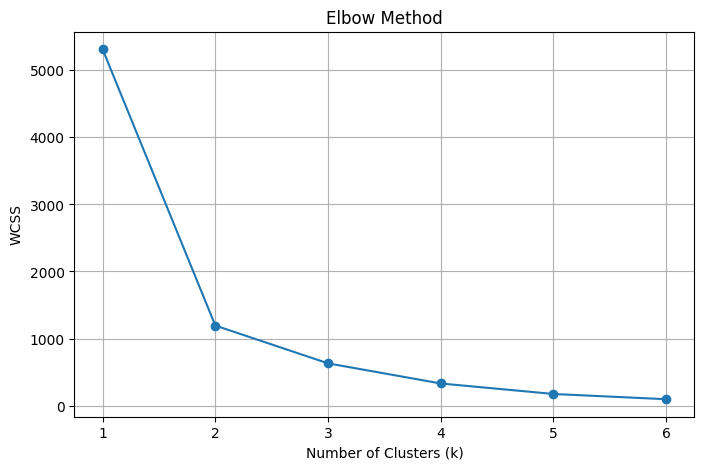


Clustered Dataset:
     song  tempo  danceability  Cluster
0  Song A     90          0.40        1
1  Song B    120          0.80        0
2  Song C    100          0.55        1
3  Song D    140          0.90        0
4  Song E    128          0.72        0
5  Song F     75          0.30        1
6  Song G    110          0.65        1
7  Song H    150          0.85        0
8  Song I     95          0.50        1
9  Song J    135          0.78        0


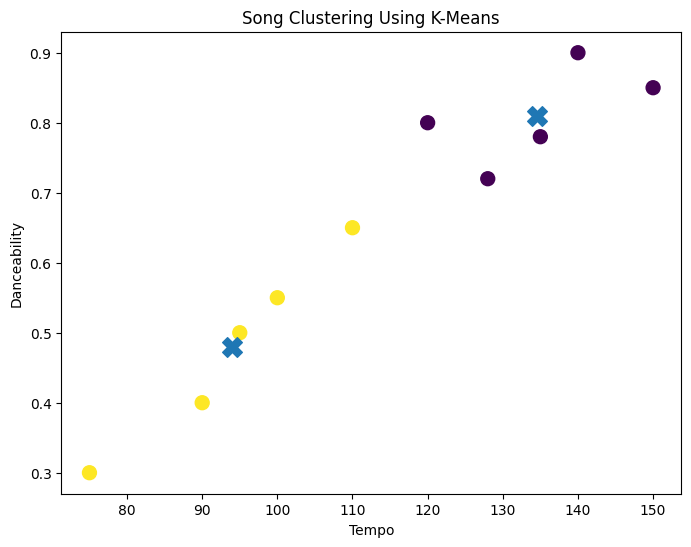

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# -----------------------------------
# 1. Load Dataset
# -----------------------------------

data = pd.read_csv("/content/sample_data/songs_tempo_danceability.csv")

# Select features
X = data[["tempo", "danceability"]]


# -----------------------------------
# 2. Elbow Method
# -----------------------------------

wcss = []

for k in range(1, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)


# -----------------------------------
# 3. Plot Elbow Curve
# -----------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 7),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.xticks(range(1, 7))
plt.grid(True)

plt.show()


# -----------------------------------
# 4. Choose Optimal K
# -----------------------------------

optimal_k = 2

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans.fit_predict(X)


# -----------------------------------
# 5. Display Results
# -----------------------------------

print("\nClustered Dataset:")
print(data)


# -----------------------------------
# 6. Plot Final Clusters
# -----------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    data["tempo"],
    data["danceability"],
    c=data["Cluster"],
    s=100
)

# Plot centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Tempo")
plt.ylabel("Danceability")
plt.title("Song Clustering Using K-Means")
plt.show()